# Configurando o Ambiente

**Configuração Modelo do Autor** 
- formula = "group ~ C(Island, Treatment(reference='Gran Canaria')) + C(Breed, Treatment(reference='Crossbreed'))"
- modelo = smf.logit(formula, data=study_filtrado).fit(disp=0)

**Sobre a Fórmula Utilizada:**

Ajuste de Variáveis (Confounding): Ao colocar Island e Breed juntas, o autor isola o efeito da raça. Isso impede que o modelo atribua um risco alto a uma raça apenas porque ela é muito comum em uma ilha que possui fatores ambientais de risco (como poluição ou dieta regional).

Estabelecimento de Baseline: O comando Treatment(reference=...) define que o "Cachorro Zero" do estudo é o Crossbreed (SRD) vivendo em Gran Canaria. Todos os outros resultados são calculados como uma variação (maior ou menor) em relação a esse padrão.

**Desempenho do Modelo do Autor (Baseline)**
- AUC-ROC: 0.789 (Quão bem ele separa doentes de saudáveis)
- Brier Score: 0.025 (Quão bem calibrada é a porcentagem. Mais baixo é melhor)

In [54]:
PALETTE = [
    "midnightblue",
    "navy",
    "darkblue",
    "mediumblue",
    "blue",
    "slateblue",
    "darkslateblue",
    "mediumslateblue",
    "mediumpurple",
    "rebeccapurple",
    "blueviolet",
    "indigo",
    "darkorchid",
    "darkviolet",
    "mediumorchid",
    "thistle",
    "plum",
    "violet",
    "purple",
    "darkmagenta",
    "fuchsia",
    "magenta",
    "orchid"
]

### Criando a Base a ser Utilizada

In [55]:
import pandas as pd

df_tumores = pd.read_csv('../data/all_tumoursFD.csv', encoding='latin1')
df_mamas = df_tumores[df_tumores['Location'] == 'Mammary gland'].copy()

df_mamas = df_mamas.dropna(subset=['Benign_Malignant'])

df_mamas['alvo_cancer'] = (df_mamas['Benign_Malignant'] == 'Malignant').astype(int)

colunas_features = ['Breed', 'Age', 'Neuter_status', 'Island']

df_modelagem = df_mamas[colunas_features + ['alvo_cancer']].copy()

# Selecionamos as colunas de interesse
colunas_features = ['Breed', 'Age', 'Neuter_status', 'Island', 'alvo_cancer']
df_modelagem['Age'] = df_modelagem['Age'].fillna(df_modelagem['Age'].median())
df_modelagem = df_mamas.dropna(subset=colunas_features).copy()

limite_caes = 16

contagem_racas = df_modelagem['Breed'].value_counts()

racas_raras = contagem_racas[contagem_racas < limite_caes].index

df_modelagem['Breed'] = df_modelagem['Breed'].replace(racas_raras, 'Other')

print(f"Agrupamos {len(racas_raras)} raças raras na categoria 'Other'.")
print("Top 5 Raças agora na base:")
print(df_modelagem['Breed'].value_counts().head())



Agrupamos 51 raças raras na categoria 'Other'.
Top 5 Raças agora na base:
Breed
Crossbreed           2556
Yorkshire Terrier    1055
Poodle                566
Cocker Spaniel        491
Other                 218
Name: count, dtype: int64


In [56]:
df_modelagem.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6632 entries, 0 to 13814
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ReportRef             6632 non-null   int64  
 1   ResultDate            6632 non-null   int64  
 2   Histo_Cyto            6632 non-null   object 
 3   Primary_tumour        6632 non-null   object 
 4   Etiqueta2_morfologia  6632 non-null   object 
 5   Etiqueta3_morfologia  6632 non-null   object 
 6   Benign_Malignant      6632 non-null   object 
 7   Grade.3.tier          4043 non-null   object 
 8   Location              6632 non-null   object 
 9   Island                6632 non-null   object 
 10  Breed                 6632 non-null   object 
 11  Age                   6632 non-null   float64
 12  Neuter_status         6632 non-null   object 
 13  Year_of_birth         6632 non-null   float64
 14  alvo_cancer           6632 non-null   int64  
dtypes: float64(2), int64(3), 

In [57]:
df_features = df_modelagem[colunas_features].copy()
df_features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6632 entries, 0 to 13814
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Breed          6632 non-null   object 
 1   Age            6632 non-null   float64
 2   Neuter_status  6632 non-null   object 
 3   Island         6632 non-null   object 
 4   alvo_cancer    6632 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 310.9+ KB


In [58]:
df_features.to_csv('../data/model_data.csv', index=False)

### Analisando Base Utilizada

In [59]:
import pandas as pd
data = pd.read_csv('../data/model_data.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6632 entries, 0 to 6631
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Breed          6632 non-null   object 
 1   Age            6632 non-null   float64
 2   Neuter_status  6632 non-null   object 
 3   Island         6632 non-null   object 
 4   alvo_cancer    6632 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 259.2+ KB


In [60]:
data.head()

,Breed,Age,Neuter_status,Island,alvo_cancer
0,Crossbreed,12.0,Entire,Gran Canaria,1
1,Crossbreed,10.0,Entire,Gran Canaria,1
2,Crossbreed,14.0,Neutered,Gran Canaria,1
3,Cocker Spaniel,7.0,Entire,Tenerife,1
4,Cocker Spaniel,7.0,Entire,Tenerife,1


In [61]:
data['alvo_cancer'].value_counts()

alvo_cancer
1    5941
0     691
Name: count, dtype: int64

- 1 = maligno, 0 = benigno

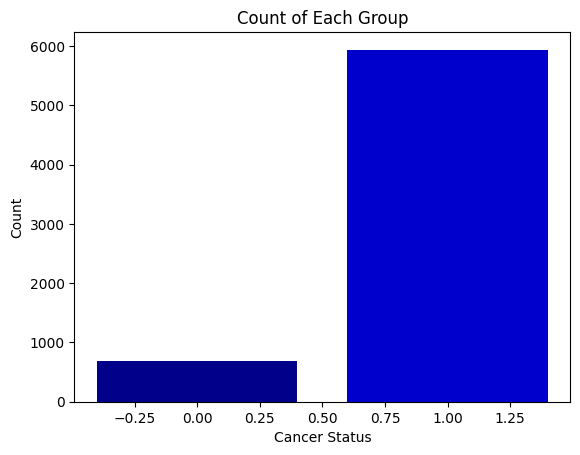

In [62]:
import matplotlib.pyplot as plt

plt.bar(
    data['alvo_cancer'].value_counts().index, 
    data['alvo_cancer'].value_counts().values, 
    color=[PALETTE[3], PALETTE[2]]
)
plt.xlabel('Cancer Status')
plt.ylabel('Count')
plt.title('Count of Each Group')
plt.savefig('../output/Group_Counts.png', dpi=300, bbox_inches='tight')
plt.show()

In [63]:
data['Breed'].value_counts()

Breed
Crossbreed                     2556
Yorkshire Terrier              1055
Poodle                          566
Cocker Spaniel                  491
Other                           218
German Shepherd Dog             199
French Bulldog                  151
Boxer                           117
Chihuahua                       111
Bichon frise                    107
Canarian Warren Hound            79
Labrador Retriever               63
West Highland White Terrier      61
Canarian Mastiff                 56
Rottweiler                       56
Dalmatian                        53
Shih-Tzu                         49
Dachshund                        46
Fox Terrier                      40
Siberian Husky                   40
German Pinscher                  35
Staffordshire Bull Terrier       35
Bulldog                          33
Pit Bull Terrier                 33
Jack Russell Terrier             30
Bull Terrier                     30
Samoyed                          28
No_info               

### Metodologia

1. Dividir dados em treino e teste 80/20
2. Treinar o modelo com cv de 5 folds
3. testar modelo

- para modelos de arvores serão utilizados random search

# Modelos

## Regressão Classica (sem penalidade)

### Modelo Base Divisão 80/20

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss
import statsmodels.formula.api as smf

df_treino, df_teste = train_test_split(
    data, 
    test_size=0.2, 
    random_state=42, 
    stratify=df_modelagem['alvo_cancer']
)

formula = (
    "alvo_cancer ~ C(Island, Treatment(reference='Gran Canaria')) + "
    "C(Breed, Treatment(reference='Crossbreed')) + "
    "Age + "
    "C(Neuter_status)"
)


In [65]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def get_metricas(y_gabarito, probs_teste):
    auc_final = roc_auc_score(y_gabarito, probs_teste)
    brier_final = brier_score_loss(y_gabarito, probs_teste)
    accuracy_final = accuracy_score(y_gabarito, probs_teste.round())
    precision_final = precision_score(y_gabarito, probs_teste.round())
    recall_final = recall_score(y_gabarito, probs_teste.round())
    f1_final = f1_score(y_gabarito, probs_teste.round())
    
    limiar = 0.5
    previsoes_binarias = (probs_teste >= limiar).astype(int)    
    tn, fp, fn, tp = confusion_matrix(y_gabarito, previsoes_binarias).ravel()
    especificidade = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    print(f"Especificidade: {especificidade:.3f}")
    print(f"AUC-ROC Final : {auc_final:.3f}")
    print(f"Brier Final   : {brier_final:.3f}")
    print(f"Accuracy Final: {accuracy_final:.3f}")
    print(f"Precision Final: {precision_final:.3f}")
    print(f"Recall Final: {recall_final:.3f}")
    print(f"F1 Score Final: {f1_final:.3f}")

In [66]:

modelo_base = smf.logit(formula, data=df_treino).fit(disp=0)

probs_teste = modelo_base.predict(df_teste)
y_gabarito = df_teste['alvo_cancer']

get_metricas(y_gabarito, probs_teste)

Especificidade: 0.000
AUC-ROC Final : 0.598
Brier Final   : 0.093
Accuracy Final: 0.896
Precision Final: 0.896
Recall Final: 1.000
F1 Score Final: 0.945


c:\Repositories\canine-mammary-tumors\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Especificidade: 0.000


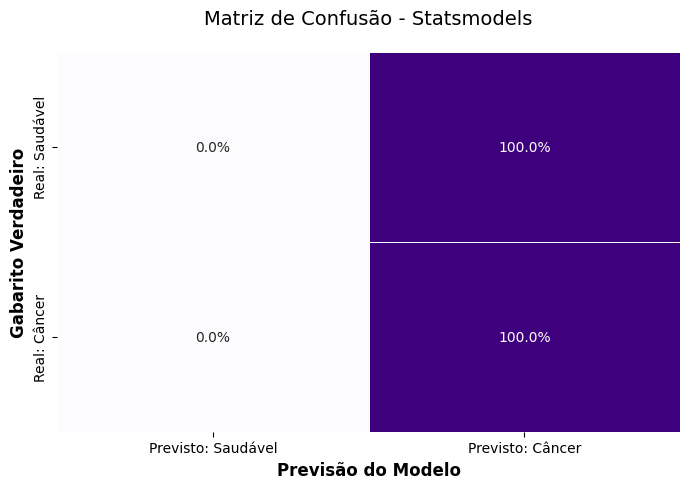

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

limiar = 0.5

previsoes_binarias = (probs_teste >= limiar).astype(int)

cm = confusion_matrix(y_gabarito, previsoes_binarias, normalize='true') 
tn, fp, fn, tp = confusion_matrix(y_gabarito, previsoes_binarias).ravel()
especificidade = tn / (tn + fp) if (tn + fp) > 0 else 0
print(f"Especificidade: {especificidade:.3f}")

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, cmap='Purples' ,fmt='.1%',
            linewidths=.5, cbar=False, vmin=0, vmax=1,
            xticklabels=['Previsto: Saudável', 'Previsto: Câncer'],
            yticklabels=['Real: Saudável', 'Real: Câncer'])


plt.title('Matriz de Confusão - Statsmodels', pad=20, fontsize=14)
plt.ylabel('Gabarito Verdadeiro', fontsize=12, fontweight='bold')
plt.xlabel('Previsão do Modelo', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/Confusion_Matrix_Statsmodels.png', dpi=300, bbox_inches='tight')
plt.show()

### Scikit Learn

#### Parâmetros

- penalty -> penalidade aplicada às variáveis
    - l2 -> Encolhe os pesos de todas as variáveis, mas não zera nenhuma. Ótimo para manter todas as raças no modelo de forma equilibrada.
    - l1 -> Zera os pesos das variáveis que não importam. Perfeito para "limpar" o modelo e manter só as raças cruciais.
    - elasticnet -> Mistura L1 e L2
    - None -> sem penalidade

- C -> É a força inversa da regularização
    - Valores altos: Menos restrição. O modelo confia muito nos dados de treino.
    - Valores baixos: Mais restrição. O modelo fica mais cético, impedindo que raças com poucos casos dominem a probabilidade.

- l1_ratio -> Só é usado se você escolher penalty='elasticnet'. Ele dita a proporção da mistura.
    - Um valor de 0.2 significa 20% Lasso (zerar variáveis) e 80% Ridge (encolher variáveis). Um valor de 0.5 é meio a meio.

- solver -> Define a engrenagem de cálculo.
    - 'lbfgs': Excelente e rápido para a maioria dos casos, mas só suporta penalidade L2 ou None.asd
    - 'liblinear': O melhor para datasets menores e é obrigatório se você quiser usar a penalidade L1 (Lasso).
    - 'saga': O único que suporta Elastic-Net. Também é muito rápido para datasets gigantescos (centenas de milhares de linhas).
    - newton-cholesky: Ele calcula a matriz de curvatura exata e a resolve usando uma técnica de álgebra linear chamada "Decomposição de Cholesky".

- class_weight -> Dá pesos diferentes para acertos e erros dependendo da classe.
    - None: Trata todos os cães com o mesmo peso.
    - 'balanced': O modelo matematicamente aumenta o "peso" do erro quando ele erra um cão com câncer. Ele força o algoritmo a prestar muito mais atenção na minoria doente para equilibrar o jogo.

- max_iter -> O número máximo de tentativas (passos) que o solver tem para achar a matemática perfeita.
    - Se você rodar o modelo e receber um aviso vermelho dizendo "ConvergenceWarning: lbfgs failed to converge", significa que o modelo precisava de mais tempo para pensar. Aumente para 500 ou 1000.


In [68]:
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.model_selection import StratifiedKFold
import numpy as np

def avaliar_modelo_cv(modelo, X, y, nome="Modelo ML", n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    auc_scores = []
    brier_scores = []
    
    print(f"Iniciando Validação Cruzada ({n_splits} folds) para: {nome}...")
    
    for fold, (train_index, val_index) in enumerate(skf.split(X, y), 1):
        
        X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
        y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]
        
        modelo.fit(X_train_fold, y_train_fold)
        
        probs = modelo.predict_proba(X_val_fold)[:, 1]
        
        auc = roc_auc_score(y_val_fold, probs)
        brier = brier_score_loss(y_val_fold, probs)
        
        auc_scores.append(auc)
        brier_scores.append(brier)
        
    auc_media = np.mean(auc_scores)
    auc_std = np.std(auc_scores)
    
    brier_media = np.mean(brier_scores)
    brier_std = np.std(brier_scores)
    
    print(f"\n[RESULTADO CV - TREINO] {nome}:")
    print(f"AUC-ROC Média  : {auc_media:.3f} (+/- {auc_std:.3f})")
    print(f"Brier Médio    : {brier_media:.3f} (+/- {brier_std:.3f})\n")
    
    return auc_media, brier_media

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def matriz_confusao_LR(y_test, y_pred, modelo):
    cm_percent = confusion_matrix(y_test, y_pred, normalize='true')

    plt.figure(figsize=(7, 5))
    
    # 2. Mudamos o fmt para '.1%' para exibir 85.5% em vez de decimais puros
    sns.heatmap(cm_percent, annot=True, fmt='.1%', cmap='Purples', 
                linewidths=.5, cbar=False, vmin=0, vmax=1,
                xticklabels=['Previsto: Saudável', 'Previsto: Câncer'],
                yticklabels=['Real: Saudável', 'Real: Câncer'])

    plt.title(f'Matriz de Confusão (%) - {modelo}', pad=20, fontsize=14)
    plt.ylabel('Gabarito Verdadeiro', fontsize=12, fontweight='bold')
    plt.xlabel('Previsão do Modelo', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../output/Confusion_Matrix_Norm_{modelo.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()


In [70]:
from sklearn.model_selection import train_test_split

dados_ml = pd.get_dummies(data, columns=['Breed', 'Island', 'Neuter_status'], drop_first=True)

X = dados_ml.drop(columns=['alvo_cancer'])
y = dados_ml['alvo_cancer']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [71]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'solver': ['lbfgs', 'newton-cg'],
    'max_iter': [100, 200, 500, 1000, 2000]
}

modelo = LogisticRegression(random_state=42, penalty=None, class_weight='balanced')

grid_search = GridSearchCV(
    estimator=modelo, 
    param_grid=param_grid,
    scoring='roc_auc', 
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print("\n--- RESULTADOS DO GRID SEARCH SEM PENALIDADE ---")
print(f"Melhor nota AUC-ROC durante o treino: {grid_search.best_score_:.3f}")
print("Melhores parâmetros encontrados:")
print(grid_search.best_params_)

melhor_modelo_sp = grid_search.best_estimator_


--- RESULTADOS DO GRID SEARCH SEM PENALIDADE ---
Melhor nota AUC-ROC durante o treino: 0.574
Melhores parâmetros encontrados:
{'max_iter': 200, 'solver': 'lbfgs'}


c:\Repositories\canine-mammary-tumors\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [72]:
probs_teste_ml = melhor_modelo_sp.predict_proba(X_test)[:, 1]

auc_final_ml = roc_auc_score(y_test, probs_teste_ml)
brier_final_ml = brier_score_loss(y_test, probs_teste_ml)

print(f"AUC-ROC Final : {auc_final_ml:.3f}")
print(f"Brier Final   : {brier_final_ml:.3f}\n")

AUC-ROC Final : 0.599
Brier Final   : 0.247



In [73]:
get_metricas(y_test, probs_teste_ml)

Especificidade: 0.565
AUC-ROC Final : 0.599
Brier Final   : 0.247
Accuracy Final: 0.546
Precision Final: 0.915
Recall Final: 0.543
F1 Score Final: 0.682


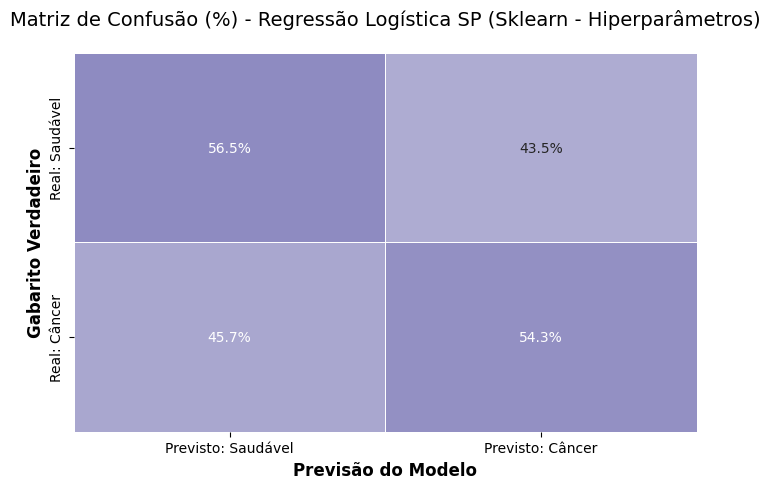

In [74]:
matriz_confusao_LR(y_test, (probs_teste_ml >= 0.5).astype(int), modelo="Regressão Logística SP (Sklearn - Hiperparâmetros)")

## Regressão Logistica ML (com penalidade)

In [75]:
param_grid = {
    'C':  [0.01, 0.1, 0.5, 1.0, 2.0, 5.0],
    'solver': ['newton-cg', 'liblinear', 'lbfgs'],
    'max_iter': [100, 200, 500, 1000, 2000]
}

modelo = LogisticRegression(random_state=42, class_weight='balanced', penalty='l2')

grid_search = GridSearchCV(
    estimator=modelo, 
    param_grid=param_grid,
    scoring='roc_auc', 
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("\n--- RESULTADOS DO GRID SEARCH COM PENALIDADE ---")
print(f"Melhor nota AUC-ROC durante o treino: {grid_search.best_score_:.3f}")
print("Melhores parâmetros encontrados:")
print(grid_search.best_params_)

melhor_modelo = grid_search.best_estimator_


--- RESULTADOS DO GRID SEARCH COM PENALIDADE ---
Melhor nota AUC-ROC durante o treino: 0.580
Melhores parâmetros encontrados:
{'C': 0.1, 'max_iter': 100, 'solver': 'lbfgs'}


c:\Repositories\canine-mammary-tumors\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [76]:
probs_teste_ml = melhor_modelo.predict_proba(X_test)[:, 1]

auc_final_ml = roc_auc_score(y_test, probs_teste_ml)
brier_final_ml = brier_score_loss(y_test, probs_teste_ml)

print(f"AUC-ROC Final : {auc_final_ml:.3f}")
print(f"Brier Final   : {brier_final_ml:.3f}\n")

AUC-ROC Final : 0.603
Brier Final   : 0.245



In [77]:
get_metricas(y_test, probs_teste_ml)

Especificidade: 0.558
AUC-ROC Final : 0.603
Brier Final   : 0.245
Accuracy Final: 0.566
Precision Final: 0.917
Recall Final: 0.567
F1 Score Final: 0.701


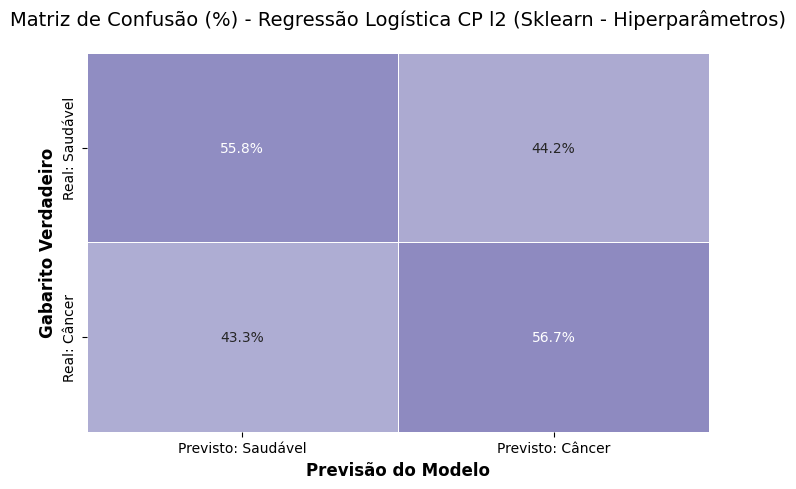

In [78]:
matriz_confusao_LR(y_test, (probs_teste_ml >= 0.5).astype(int), modelo="Regressão Logística CP l2 (Sklearn - Hiperparâmetros)")

In [79]:
param_grid = {
    'C':  [0.01, 0.1, 0.5, 1.0, 2.0, 5.0],
    'solver': ['liblinear'],
    'max_iter': [100, 200, 500, 1000, 2000]
}

modelo = LogisticRegression(random_state=42, class_weight='balanced', penalty='l1')

grid_search = GridSearchCV(
    estimator=modelo, 
    param_grid=param_grid,
    scoring='roc_auc', 
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("\n--- RESULTADOS DO GRID SEARCH COM PENALIDADE ---")
print(f"Melhor nota AUC-ROC durante o treino: {grid_search.best_score_:.3f}")
print("Melhores parâmetros encontrados:")
print(grid_search.best_params_)

melhor_modelo = grid_search.best_estimator_


--- RESULTADOS DO GRID SEARCH COM PENALIDADE ---
Melhor nota AUC-ROC durante o treino: 0.582
Melhores parâmetros encontrados:
{'C': 0.5, 'max_iter': 100, 'solver': 'liblinear'}


In [80]:
probs_teste_ml = melhor_modelo.predict_proba(X_test)[:, 1]

auc_final_ml = roc_auc_score(y_test, probs_teste_ml)
brier_final_ml = brier_score_loss(y_test, probs_teste_ml)

print(f"AUC-ROC Final : {auc_final_ml:.3f}")
print(f"Brier Final   : {brier_final_ml:.3f}\n")

AUC-ROC Final : 0.599
Brier Final   : 0.246



In [81]:
get_metricas(y_test, probs_teste_ml)

Especificidade: 0.587
AUC-ROC Final : 0.599
Brier Final   : 0.246
Accuracy Final: 0.555
Precision Final: 0.920
Recall Final: 0.551
F1 Score Final: 0.689


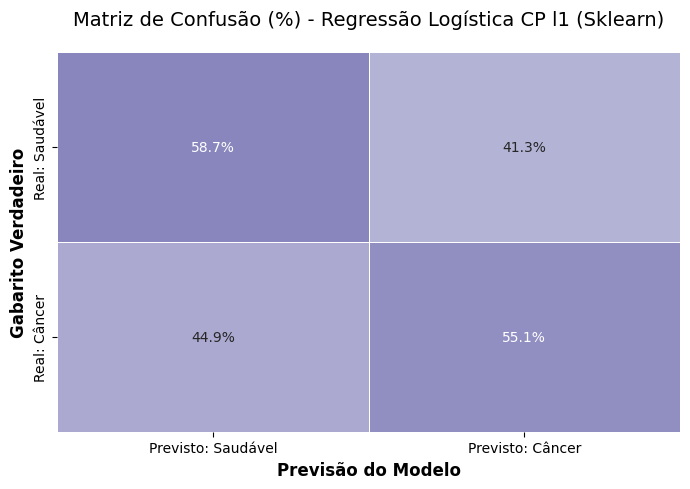

In [82]:
matriz_confusao_LR(y_test, (probs_teste_ml >= 0.5).astype(int), modelo="Regressão Logística CP l1 (Sklearn)")

## Modelos de Árvores

### Random Forest

#### Parâmetros

- n_estimators -> número de árvores (quantidade de decisores)
    - Geralmente, quanto mais, melhor a performance e mais estável é o modelo. No entanto, o custo computacional aumenta (demora mais para treinar). Chega um ponto em que adicionar mais árvores não melhora o modelo (retorno decrescente).

- max_depth -> A profundidade máxima da árvore (tomar cuidado com overfiting)
    - Controla o número máximo de "níveis" ou perguntas que a árvore pode fazer antes de dar uma resposta. Se for None, a árvore cresce até que todas as folhas sejam "puras" (contenham apenas uma classe).

- min_samples_split -> O número mínimo de amostras necessárias para dividir um nó interno.
    - Se um nó tem 5 amostras e você definiu esse valor como 10, a árvore para de dividir ali, mesmo que ainda não seja uma folha pura. Aumentar esse valor (ex: 5, 10, 20) força a árvore a ser mais generalista e menos sensível a pequenos ruídos nos dados.

- min_samples_leaf -> O número mínimo de amostras que uma folha (o nó final que dá a decisão) deve ter.
    - Semelhante ao min_samples_split, mas foca no final da árvore. Se uma divisão fosse criar uma folha com apenas 1 amostra, a divisão não acontece. Aumentar esse valor (ex: 2, 5, 10) também previne overfitting, suavizando o modelo.

- max_leaf_nodes -> O número máximo de folhas que a árvore pode ter.
    - É uma forma alternativa de limitar o crescimento, focando no número total de resultados possíveis por árvore.

- max_features -> O número máximo de características (features) que o modelo pode considerar ao procurar a melhor divisão em cada nó.
    - 'sqrt': Usa a raiz quadrada do número total de features (o padrão e geralmente o melhor para classificação).
    - 'log2': Usa o logaritmo na base 2.
    - None: Usa todas as features (nesse caso, vira uma técnica chamada Bagging e perde um pouco da vantagem do Random Forest).

- bootstrap -> Se as amostras são retiradas com reposição (Bootstrap) ao construir as árvores.
    - Em vez de treinar cada árvore com os mesmos 100% dos dados, cada árvore recebe um subconjunto aleatório (com o mesmo tamanho do original, mas algumas linhas são repetidas e outras ignoradas). Isso é fundamental para a diversidade das árvores.

- max_samples (Padrão = None) -> (Usado apenas se bootstrap=True). A porcentagem máxima de amostras a ser usada para treinar cada árvore. Se você tiver 1 milhão de linhas, pode querer que cada árvore use apenas 50% delas para treinar mais rápido, sem perder a diversidade.

- class_weigt -> peso das classes


#### Referências

Definir um espaço de busca focado
Em bases com muitas linhas e poucas features, é comum restringir o tuning a:

- n_estimators: variar em uma faixa de valores médios/altos até o ganho marginal desaparecer.

- max_features: testar valores padrão (por exemplo, sqrt(p)) e usar todas as features.

- min_samples_leaf e min_samples_split: aumentar levemente em relação ao padrão para evitar folhas extremamente pequenas em dados numerosos.

- class_weight: comparar None, 'balanced' e alguns conjuntos de pesos manuais para a classe minoritária, ou utilizar uma implementação de Balanced Random Forest.

https://www.mdpi.com/2076-3417/12/14/7253 -> base
- XG boost
    - parameter   Search Type     Search Space Range
    - gamma	continuous	[5.0, 11.0]
    - learning rate	continuous	[0.07, 0.6]
    - n estimators	discrete	50, 100, 150
    - regulation alpha	discrete	1 × 10^−5, 1 × 10^−2 ,0.75
    - regulation lambda	discrete	1 × 10^−5, 1 × 10^−2 ,0.45
    - min child weight	discrete	1.5, 6, 10
    - subsample	discrete	0.6, 0.95
    - max depth	discrete	3, 6, 9

- RF
    - parameter   Search Type     Search Space Range
    - n estimators	discrete	100, 200, 500
    - max depth	discrete	4, 5, 6, ..., 11
    - min samples	discrete	2, 3, 4, 5
    - min samples leaf	discrete	1, 3, 5, 7

In [83]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint 


param_dist = {
    'n_estimators': randint(100, 1001),         
    'max_depth': randint(3, 31),  
    'min_samples_split': randint(2, 21),     
    'min_samples_leaf': randint(1, 21),
    "max_features": ["sqrt", "log2"],      
}

rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')
random_search = RandomizedSearchCV(
    estimator=rf_base, 
    param_distributions=param_dist, 
    n_iter=1000, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1,
    random_state=42, 
)
random_search.fit(X_train, y_train)


print("\n--- RESULTADOS DO RANDOM SEARCH ---")
print(f"Melhor nota AUC-ROC durante o treino: {random_search.best_score_:.3f}")
print("Melhores parâmetros sorteados e encontrados:")
print(random_search.best_params_)

melhor_rf_random = random_search.best_estimator_


--- RESULTADOS DO RANDOM SEARCH ---
Melhor nota AUC-ROC durante o treino: 0.579
Melhores parâmetros sorteados e encontrados:
{'max_depth': 9, 'max_features': 'sqrt', 'min_samples_leaf': 14, 'min_samples_split': 18, 'n_estimators': 373}


In [84]:
probs_teste_ml = melhor_rf_random.predict_proba(X_test)[:, 1]

auc_final_ml = roc_auc_score(y_test, probs_teste_ml)
brier_final_ml = brier_score_loss(y_test, probs_teste_ml)

print(f"AUC-ROC Final : {auc_final_ml:.3f}")
print(f"Brier Final   : {brier_final_ml:.3f}\n")

AUC-ROC Final : 0.605
Brier Final   : 0.238



In [85]:
get_metricas(y_test, probs_teste_ml)

Especificidade: 0.572
AUC-ROC Final : 0.605
Brier Final   : 0.238
Accuracy Final: 0.583
Precision Final: 0.922
Recall Final: 0.584
F1 Score Final: 0.715


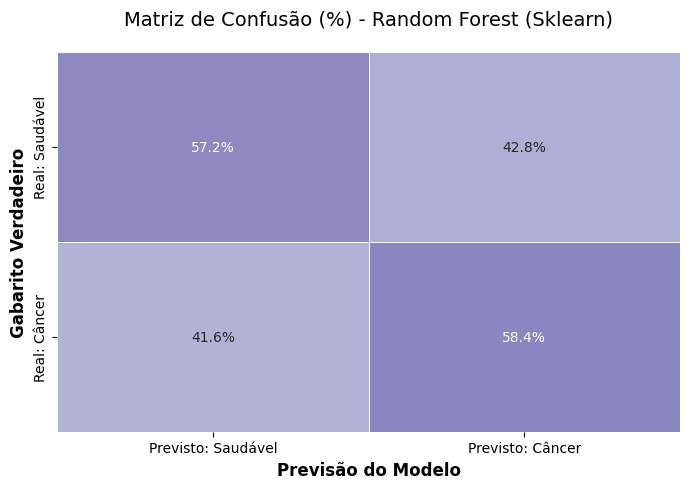

In [86]:
matriz_confusao_LR(y_test, (probs_teste_ml >= 0.5).astype(int), modelo="Random Forest (Sklearn)")

https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=11413460

http://join.if.uinsgd.ac.id/index.php/join/article/view/1590/364

### XGboost

In [87]:
import scipy
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from scipy.stats import randint, uniform, loguniform

contagem_classes = y_train.value_counts()
peso_positivo = contagem_classes[0] / contagem_classes[1] 
print(f"O scale_pos_weight calculado foi: {peso_positivo:.2f}\n")

param_dist = {
    "n_estimators": scipy.stats.randint(100, 1001),
    "learning_rate": scipy.stats.uniform(0.01, 0.29),
    "max_depth": scipy.stats.randint(3, 11),
    "subsample": scipy.stats.uniform(0.5, 0.5),
    "colsample_bytree": scipy.stats.uniform(0.5, 0.5),
    "min_child_weight": scipy.stats.randint(1, 11),
    "gamma": scipy.stats.uniform(0.0, 5.0),
    "reg_lambda": scipy.stats.uniform(0.0, 10.0),
    "reg_alpha": scipy.stats.uniform(0.0, 10.0),
}

xgb_base = XGBClassifier(
    random_state=42, 
    scale_pos_weight=peso_positivo,
    eval_metric='auc', 
    use_label_encoder=False 
)

random_search = RandomizedSearchCV(
    estimator=xgb_base, 
    param_distributions=param_dist, 
    n_iter=1000, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1, 
    random_state=42,
)

random_search.fit(X_train, y_train)

print("\n--- RESULTADOS DO RANDOM SEARCH (XGBOOST) ---")
print(f"Melhor nota AUC-ROC durante o treino (CV): {random_search.best_score_:.3f}")
print("Melhores parâmetros encontrados:")
for param, valor in random_search.best_params_.items():
    if isinstance(valor, float):
        print(f"  {param}: {valor:.3f}")
    else:
        print(f"  {param}: {valor}")

melhor_xgb_random = random_search.best_estimator_

O scale_pos_weight calculado foi: 0.12



c:\Repositories\canine-mammary-tumors\.venv\lib\site-packages\xgboost\training.py:200: UserWarning: [20:39:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- RESULTADOS DO RANDOM SEARCH (XGBOOST) ---
Melhor nota AUC-ROC durante o treino (CV): 0.581
Melhores parâmetros encontrados:
  colsample_bytree: 0.562
  gamma: 0.353
  learning_rate: 0.274
  max_depth: 7
  min_child_weight: 1
  n_estimators: 919
  reg_alpha: 8.647
  reg_lambda: 1.187
  subsample: 0.586


In [88]:
probs_teste_ml = melhor_xgb_random.predict_proba(X_test)[:, 1]

auc_final_ml = roc_auc_score(y_test, probs_teste_ml)
brier_final_ml = brier_score_loss(y_test, probs_teste_ml)

print(f"AUC-ROC Final : {auc_final_ml:.3f}")
print(f"Brier Final   : {brier_final_ml:.3f}\n")

AUC-ROC Final : 0.583
Brier Final   : 0.246



In [89]:
get_metricas(y_test, probs_teste_ml)

Especificidade: 0.601
AUC-ROC Final : 0.583
Brier Final   : 0.246
Accuracy Final: 0.546
Precision Final: 0.921
Recall Final: 0.539
F1 Score Final: 0.680


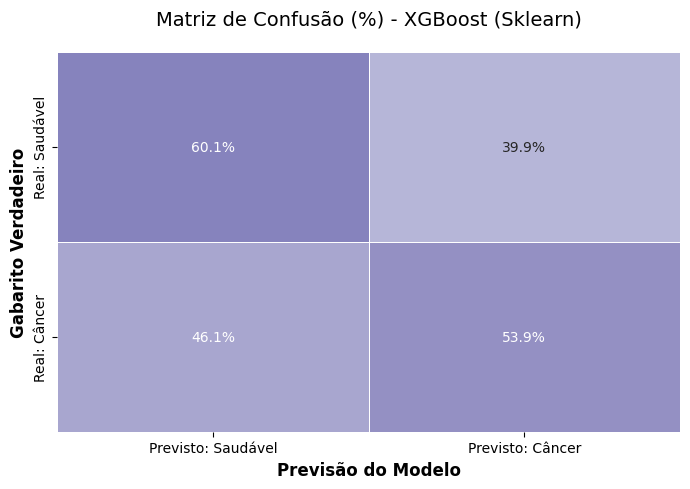

In [90]:
matriz_confusao_LR(y_test, (probs_teste_ml >= 0.5).astype(int), modelo="XGBoost (Sklearn)")

- !!!! O puro não deve existir [ok]
- Min e max de gridsearch devem ter embasamento
- Trazer todas as métricas possíveis Acc, recall, precisão, f1-score e especificidade
- SMOTE em todos os modelos

## Modelos SMOTE

### Preparando Dados Treino

In [91]:
from imblearn.over_sampling import SMOTE
import pandas as pd

X_treino_ml = pd.get_dummies(df_treino[['Breed', 'Island', 'Neuter_status', 'Age']], drop_first=True)
y_treino_ml = df_treino['alvo_cancer']

X_teste_ml = pd.get_dummies(df_teste[['Breed', 'Island', 'Neuter_status', 'Age']], drop_first=True)
y_teste_ml = df_teste['alvo_cancer']

X_treino_ml, X_teste_ml = X_treino_ml.align(X_teste_ml, join='left', axis=1, fill_value=0)

print(y_treino_ml.value_counts())

smote = SMOTE(random_state=42)

# Gera os dados sintéticos apenas para o treino
X_treino_smote, y_treino_smote = smote.fit_resample(X_treino_ml, y_treino_ml)

print(y_treino_smote.value_counts())

alvo_cancer
1    4752
0     553
Name: count, dtype: int64
alvo_cancer
1    4752
0    4752
Name: count, dtype: int64


### Regressão Logistica SP

In [92]:
param_grid = {
    'solver': ['lbfgs', 'newton-cg'],
    'max_iter': [100, 200, 500, 1000, 2000]
}

modelo = LogisticRegression(random_state=42, penalty=None)

grid_search = GridSearchCV(
    estimator=modelo, 
    param_grid=param_grid,
    scoring='roc_auc', 
    n_jobs=-1,
)
grid_search.fit(X_treino_smote, y_treino_smote)

print("\n--- RESULTADOS DO GRID SEARCH SEM PENALIDADE ---")
print(f"Melhor nota AUC-ROC durante o treino: {grid_search.best_score_:.3f}")
print("Melhores parâmetros encontrados:")
print(grid_search.best_params_)

melhor_modelo_sp = grid_search.best_estimator_


--- RESULTADOS DO GRID SEARCH SEM PENALIDADE ---
Melhor nota AUC-ROC durante o treino: 0.771
Melhores parâmetros encontrados:
{'max_iter': 500, 'solver': 'lbfgs'}


In [93]:
probs_teste_ml = melhor_modelo.predict_proba(X_test)[:, 1]
get_metricas(y_test, probs_teste_ml)

Especificidade: 0.587
AUC-ROC Final : 0.599
Brier Final   : 0.246
Accuracy Final: 0.555
Precision Final: 0.920
Recall Final: 0.551
F1 Score Final: 0.689


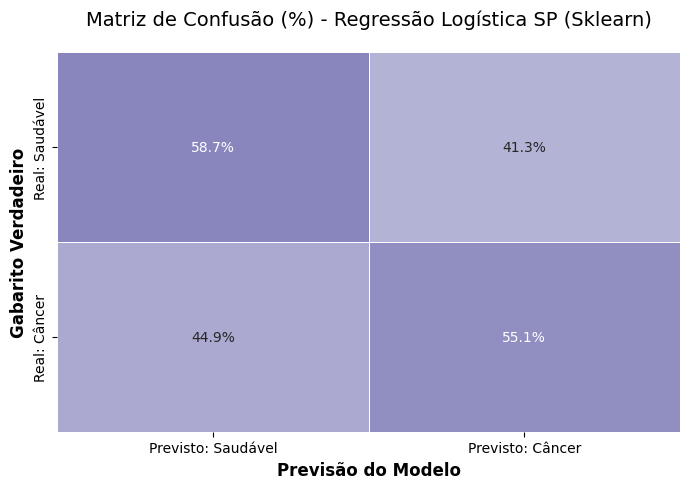

In [94]:
matriz_confusao_LR(y_test, (probs_teste_ml >= 0.5).astype(int), modelo="Regressão Logística SP (Sklearn)")

### Regressão Logística CP

In [95]:
param_grid = {
    'C':  [0.01, 0.1, 0.5, 1.0, 2.0, 5.0],
    'solver': ['newton-cg', 'liblinear', 'lbfgs'],
    'max_iter': [100, 200, 500, 1000, 2000]
}

modelo = LogisticRegression(random_state=42, penalty='l2')

grid_search = GridSearchCV(
    estimator=modelo, 
    param_grid=param_grid,
    scoring='roc_auc', 
    n_jobs=-1
)
grid_search.fit(X_treino_smote, y_treino_smote)

print("\n--- RESULTADOS DO GRID SEARCH COM PENALIDADE ---")
print(f"Melhor nota AUC-ROC durante o treino: {grid_search.best_score_:.3f}")
print("Melhores parâmetros encontrados:")
print(grid_search.best_params_)

melhor_modelo = grid_search.best_estimator_


--- RESULTADOS DO GRID SEARCH COM PENALIDADE ---
Melhor nota AUC-ROC durante o treino: 0.770
Melhores parâmetros encontrados:
{'C': 5.0, 'max_iter': 100, 'solver': 'liblinear'}


In [96]:
probs_teste_ml = melhor_modelo.predict_proba(X_test)[:, 1]
get_metricas(y_test, probs_teste_ml)

Especificidade: 0.319
AUC-ROC Final : 0.584
Brier Final   : 0.193
Accuracy Final: 0.685
Precision Final: 0.902
Recall Final: 0.728
F1 Score Final: 0.805


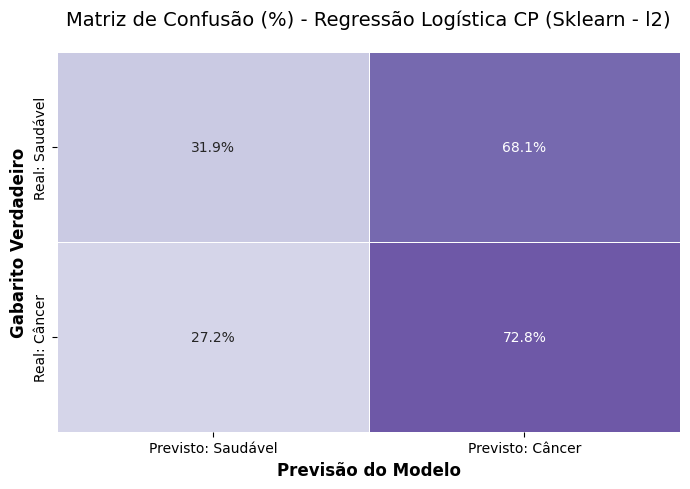

In [97]:
matriz_confusao_LR(y_test, (probs_teste_ml >= 0.5).astype(int), modelo="Regressão Logística CP (Sklearn - l2)")

In [98]:
param_grid = {
    'C':  [0.01, 0.1, 0.5, 1.0, 2.0, 5.0],
    'solver': ['liblinear'],
    'max_iter': [100, 200, 500, 1000, 2000]
}

modelo = LogisticRegression(random_state=42, penalty='l1')

grid_search = GridSearchCV(
    estimator=modelo, 
    param_grid=param_grid,
    scoring='roc_auc', 
    n_jobs=-1
)
grid_search.fit(X_treino_smote, y_treino_smote)

print("\n--- RESULTADOS DO GRID SEARCH COM PENALIDADE ---")
print(f"Melhor nota AUC-ROC durante o treino: {grid_search.best_score_:.3f}")
print("Melhores parâmetros encontrados:")
print(grid_search.best_params_)

melhor_modelo = grid_search.best_estimator_


--- RESULTADOS DO GRID SEARCH COM PENALIDADE ---
Melhor nota AUC-ROC durante o treino: 0.771
Melhores parâmetros encontrados:
{'C': 5.0, 'max_iter': 100, 'solver': 'liblinear'}


c:\Repositories\canine-mammary-tumors\.venv\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [99]:
probs_teste_ml = melhor_modelo.predict_proba(X_test)[:, 1]
get_metricas(y_test, probs_teste_ml)

Especificidade: 0.319
AUC-ROC Final : 0.583
Brier Final   : 0.192
Accuracy Final: 0.690
Precision Final: 0.903
Recall Final: 0.733
F1 Score Final: 0.809


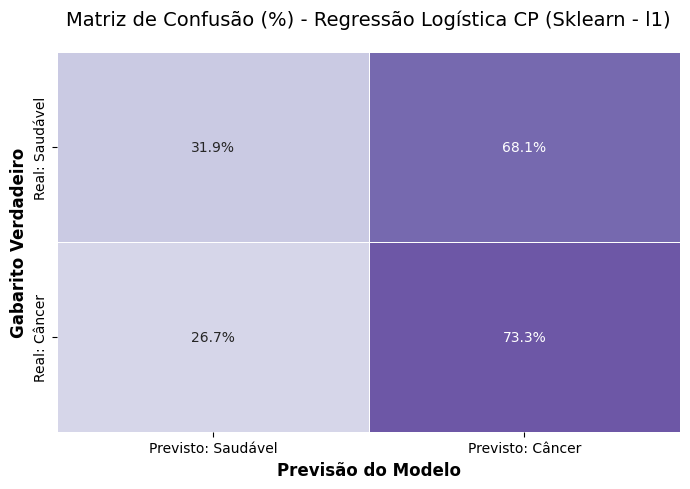

In [100]:
matriz_confusao_LR(y_test, (probs_teste_ml >= 0.5).astype(int), modelo="Regressão Logística CP (Sklearn - l1)")

### Random Forest

In [101]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint 


param_dist = {
    'n_estimators': randint(100, 1001),         
    'max_depth': randint(3, 31),  
    'min_samples_split': randint(2, 21),     
    'min_samples_leaf': randint(1, 21),
    "max_features": ["sqrt", "log2"],      
}

rf_base = RandomForestClassifier(random_state=42)
random_search = RandomizedSearchCV(
    estimator=rf_base, 
    param_distributions=param_dist, 
    n_iter=1000, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1,
    random_state=42, 
)
random_search.fit(X_treino_smote, y_treino_smote)


print("\n--- RESULTADOS DO RANDOM SEARCH ---")
print(f"Melhor nota AUC-ROC durante o treino: {random_search.best_score_:.3f}")
print("Melhores parâmetros sorteados e encontrados:")
print(random_search.best_params_)

melhor_rf_random = random_search.best_estimator_


--- RESULTADOS DO RANDOM SEARCH ---
Melhor nota AUC-ROC durante o treino: 0.856
Melhores parâmetros sorteados e encontrados:
{'max_depth': 30, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 632}


In [102]:
probs_teste_ml = melhor_rf_random.predict_proba(X_test)[:, 1]
get_metricas(y_test, probs_teste_ml)

Especificidade: 0.290
AUC-ROC Final : 0.563
Brier Final   : 0.178
Accuracy Final: 0.720
Precision Final: 0.903
Recall Final: 0.770
F1 Score Final: 0.832


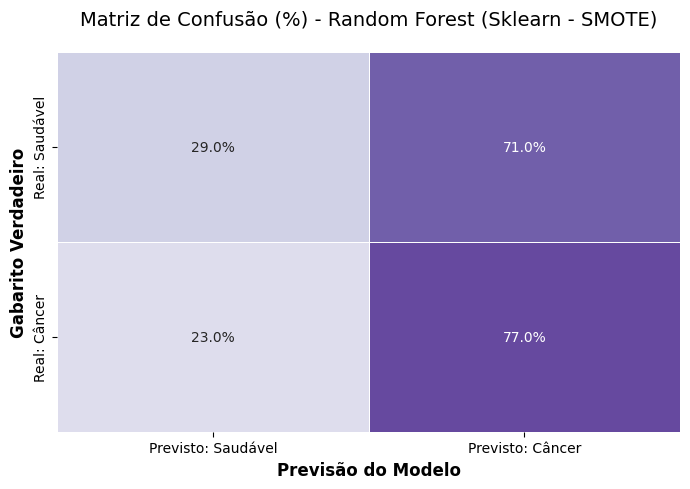

In [103]:
matriz_confusao_LR(y_test, (probs_teste_ml >= 0.5).astype(int), modelo="Random Forest (Sklearn - SMOTE)")

### XGBoost

In [104]:
import scipy
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from scipy.stats import randint, uniform, loguniform

contagem_classes = y_treino_smote.value_counts()
peso_positivo = contagem_classes[0] / contagem_classes[1] 
print(f"O scale_pos_weight calculado foi: {peso_positivo:.2f}\n")

param_dist = {
    "n_estimators": scipy.stats.randint(100, 1001),
    "learning_rate": scipy.stats.uniform(0.01, 0.29),
    "max_depth": scipy.stats.randint(3, 11),
    "subsample": scipy.stats.uniform(0.5, 0.5),
    "colsample_bytree": scipy.stats.uniform(0.5, 0.5),
    "min_child_weight": scipy.stats.randint(1, 11),
    "gamma": scipy.stats.uniform(0.0, 5.0),
    "reg_lambda": scipy.stats.uniform(0.0, 10.0),
    "reg_alpha": scipy.stats.uniform(0.0, 10.0),
}

xgb_base = XGBClassifier(
    random_state=42, 
    scale_pos_weight=peso_positivo,
    eval_metric='auc', 
    use_label_encoder=False 
)

random_search = RandomizedSearchCV(
    estimator=xgb_base, 
    param_distributions=param_dist, 
    n_iter=1000, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1, 
    random_state=42,
)

random_search.fit(X_treino_smote, y_treino_smote)

print("\n--- RESULTADOS DO RANDOM SEARCH (XGBOOST) ---")
print(f"Melhor nota AUC-ROC durante o treino (CV): {random_search.best_score_:.3f}")
print("Melhores parâmetros encontrados:")
for param, valor in random_search.best_params_.items():
    if isinstance(valor, float):
        print(f"  {param}: {valor:.3f}")
    else:
        print(f"  {param}: {valor}")

melhor_xgb_random = random_search.best_estimator_

O scale_pos_weight calculado foi: 1.00



c:\Repositories\canine-mammary-tumors\.venv\lib\site-packages\xgboost\training.py:200: UserWarning: [21:02:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- RESULTADOS DO RANDOM SEARCH (XGBOOST) ---
Melhor nota AUC-ROC durante o treino (CV): 0.855
Melhores parâmetros encontrados:
  colsample_bytree: 0.975
  gamma: 0.735
  learning_rate: 0.279
  max_depth: 4
  min_child_weight: 1
  n_estimators: 607
  reg_alpha: 0.662
  reg_lambda: 0.459
  subsample: 0.810


In [105]:
probs_teste_ml = melhor_xgb_random.predict_proba(X_test)[:, 1]
get_metricas(y_test, probs_teste_ml)

Especificidade: 0.370
AUC-ROC Final : 0.594
Brier Final   : 0.174
Accuracy Final: 0.755
Precision Final: 0.916
Recall Final: 0.800
F1 Score Final: 0.854


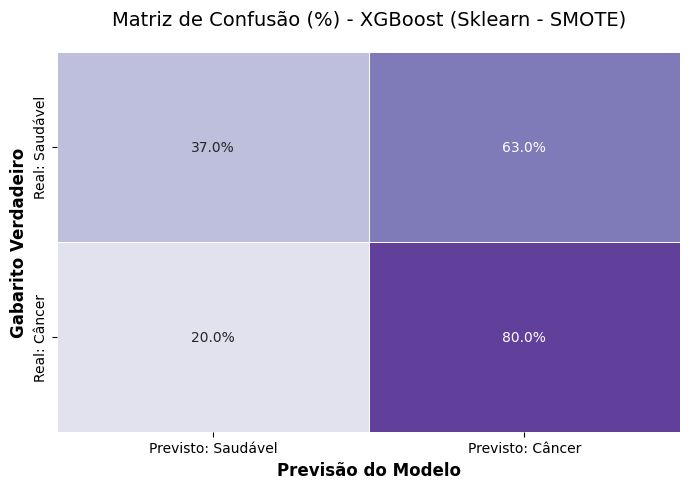

In [106]:
matriz_confusao_LR(y_test, (probs_teste_ml >= 0.5).astype(int), modelo="XGBoost (Sklearn - SMOTE)")   